# RDX Distillation Experiments — Paper-Ready Plots

Test accuracy and train loss curves for CIFAR-100 (resnet8x4 ← resnet32x4).
Figures are grouped by experiment type; KD and CRD baselines appear in each for comparison.

In [1]:
import csv
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

import seaborn as sns
sns.set_theme(style='whitegrid', font='serif', font_scale=1.1)


plt.rcParams.update({
    'font.family': 'serif',
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

DATA_PATH = Path('../save/tensorboard_export/experiments.csv')

In [5]:
RUN_LABELS = {
    'S:resnet8x4_T:resnet32x4_cifar100_kd_r:0.1_a:0.9_b:0.0_1': 'KD (baseline)',
    'S:resnet8x4_T:resnet32x4_cifar100_crd_r:1_a:0.0_b:0.8_1': 'CRD (baseline)',
    'S:resnet8x4_T:resnet32x4_cifar100_rkd_r:1_a:0.0_b:1.0_1': 'RKD (baseline)',
    'S:resnet8x4_T:resnet32x4_cifar100_kd_r:0.1_a:0.9_b:0.0_rdx0.15_1': 'RDX Sampling',
    'S:resnet8x4_T:resnet32x4_cifar100_kd_r:0.1_a:0.9_b:0.0_rdx0.15_2': 'RDX Sampling + refresh',
    'S:resnet8x4_T:resnet32x4_cifar100_kd_r:0.1_a:0.9_b:0.0_curr0.3-100e_3': 'RDX Curriculum',
    'S:resnet8x4_T:resnet32x4_cifar100_rdx_triplet_r:0.1_a:0.9_b:0.5_1': 'KD + RDD (unweighted)',
    'S:resnet8x4_T:resnet32x4_cifar100_rdx_triplet_r:0.1_a:0.9_b:0.5_2': 'KD + RDD',
    'S:resnet8x4_T:resnet32x4_cifar100_rdx_triplet_r:0.1_a:0.9_b:10.0_1': 'KD + RDD (β=10)',
    'S:resnet8x4_T:resnet32x4_cifar100_rdx_triplet_r:1_a:0.0_b:0.8_1': 'RDD only',
}

ORDER = [
    'KD (baseline)',
    'CRD (baseline)',
    'RKD (baseline)',
    'RDX Sampling',
    'RDX Sampling + refresh',
    'RDX Curriculum',
    'KD + RDD (unweighted)',
    'KD + RDD',
    'KD + RDD (β=10)',
    'RDD only',
]

COLORS = {
    'KD (baseline)': '#2d2d2d',
    'CRD (baseline)': '#e74c3c',
    'RKD (baseline)': '#7f8c8d',
    'RDX Sampling': '#3498db',
    'RDX Sampling + refresh': '#5dade2',
    'RDX Curriculum': '#27ae60',
    'KD + RDD (unweighted)': '#8e44ad',
    'KD + RDD': '#9b59b6',
    'KD + RDD (β=10)': '#16a085',
    'RDD only': '#d35400',
}

LINESTYLES = {
    'KD (baseline)': '-',
    'CRD (baseline)': '-',
    'RKD (baseline)': '--',
    'RDX Sampling': '-',
    'RDX Sampling + refresh': '--',
    'RDX Curriculum': '-',
    'KD + RDD (unweighted)': '--',
    'KD + RDD': '-',
    'KD + RDD (β=10)': '-.',
    'RDD only': '-',
}

rows = []
with open(DATA_PATH) as f:
    r = csv.DictReader(f)
    for row in r:
        label = RUN_LABELS.get(row['run'])
        if label:
            rows.append({
                'label': label,
                'step': int(row['step']),
                'tag': row['tag'],
                'value': float(row['value'])
            })

def pivot_run(rows, tag):
    out = defaultdict(list)
    for r in rows:
        if r['tag'] == tag:
            out[r['label']].append((r['step'], r['value']))
    return {k: (tuple(zip(*sorted(v)))) for k, v in out.items()}

def smooth_curve(steps, values, alpha=0.6):
    """Exponential moving average. Higher alpha = more smoothing."""
    vals = list(values)
    smoothed = [vals[0]]
    for i in range(1, len(vals)):
        smoothed.append(alpha * smoothed[-1] + (1 - alpha) * vals[i])
    return steps, smoothed

SMOOTH = 0.6

test_acc = pivot_run(rows, 'test_acc')
train_loss = pivot_run(rows, 'train_loss')
print('Loaded', len(rows), 'rows. Runs:', list(test_acc.keys()))

Loaded 10545 rows. Runs: ['CRD (baseline)', 'KD (baseline)', 'RDX Curriculum', 'RDX Sampling', 'RDX Sampling + refresh', 'KD + RDD (unweighted)', 'KD + RDD', 'KD + RDD (β=10)', 'RDD only', 'RKD (baseline)']


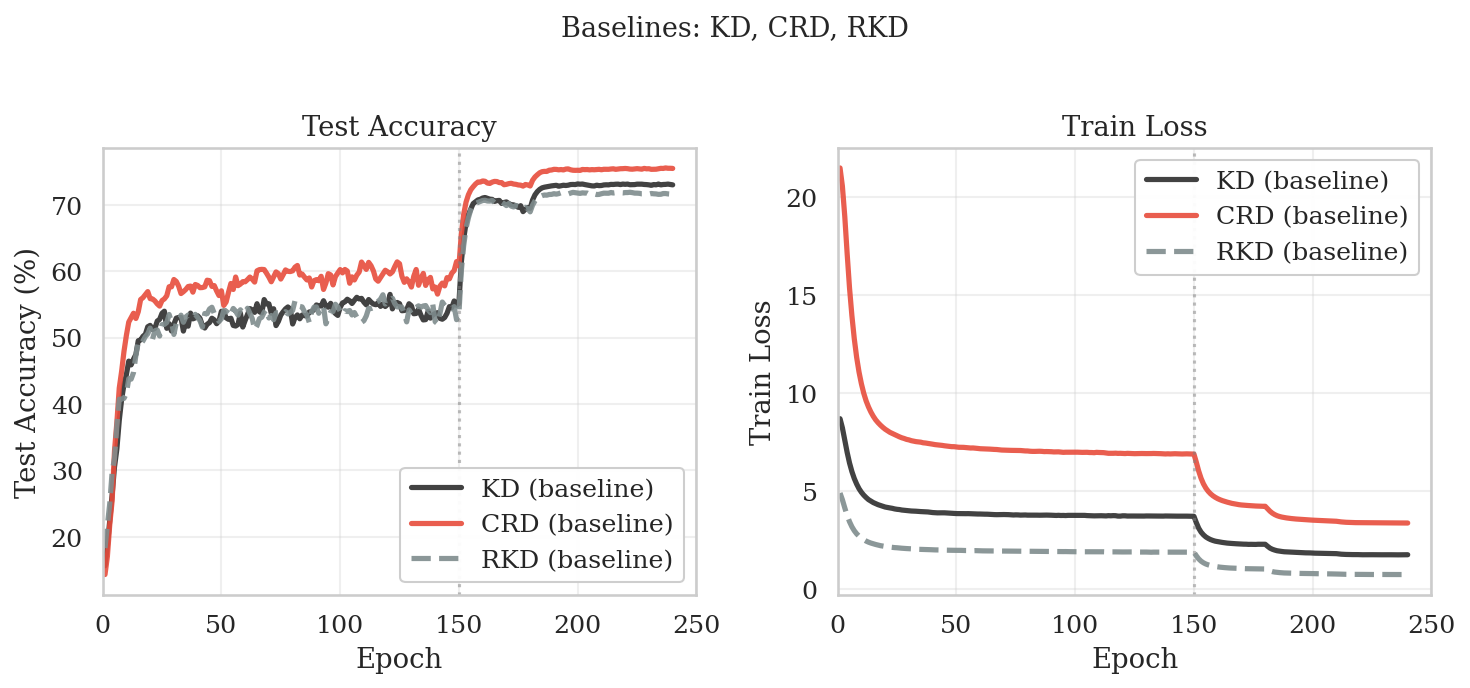

In [6]:
# Figure 1: Baselines (KD, CRD, RKD)
FIG1_LABELS = ['KD (baseline)', 'CRD (baseline)', 'RKD (baseline)']

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for label in FIG1_LABELS:
    if label not in test_acc:
        continue
    steps, vals = smooth_curve(*test_acc[label], alpha=SMOOTH)
    axes[0].plot(steps, vals, label=label, color=COLORS[label],
                 linestyle=LINESTYLES[label], linewidth=2.5, alpha=0.9)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Test Accuracy')
axes[0].legend(loc='lower right', framealpha=0.95)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 250)
axes[0].axvline(150, color='gray', linestyle=':', alpha=0.5)

for label in FIG1_LABELS:
    if label not in train_loss:
        continue
    steps, vals = smooth_curve(*train_loss[label], alpha=SMOOTH)
    axes[1].plot(steps, vals, label=label, color=COLORS[label],
                 linestyle=LINESTYLES[label], linewidth=2.5, alpha=0.9)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Train Loss')
axes[1].set_title('Train Loss')
axes[1].legend(loc='upper right', framealpha=0.95)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 250)
axes[1].axvline(150, color='gray', linestyle=':', alpha=0.5)

fig.suptitle('Baselines: KD, CRD, RKD', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../save/tensorboard_export/fig1_baselines.pdf')
plt.savefig('../save/tensorboard_export/fig1_baselines.png')
plt.show()

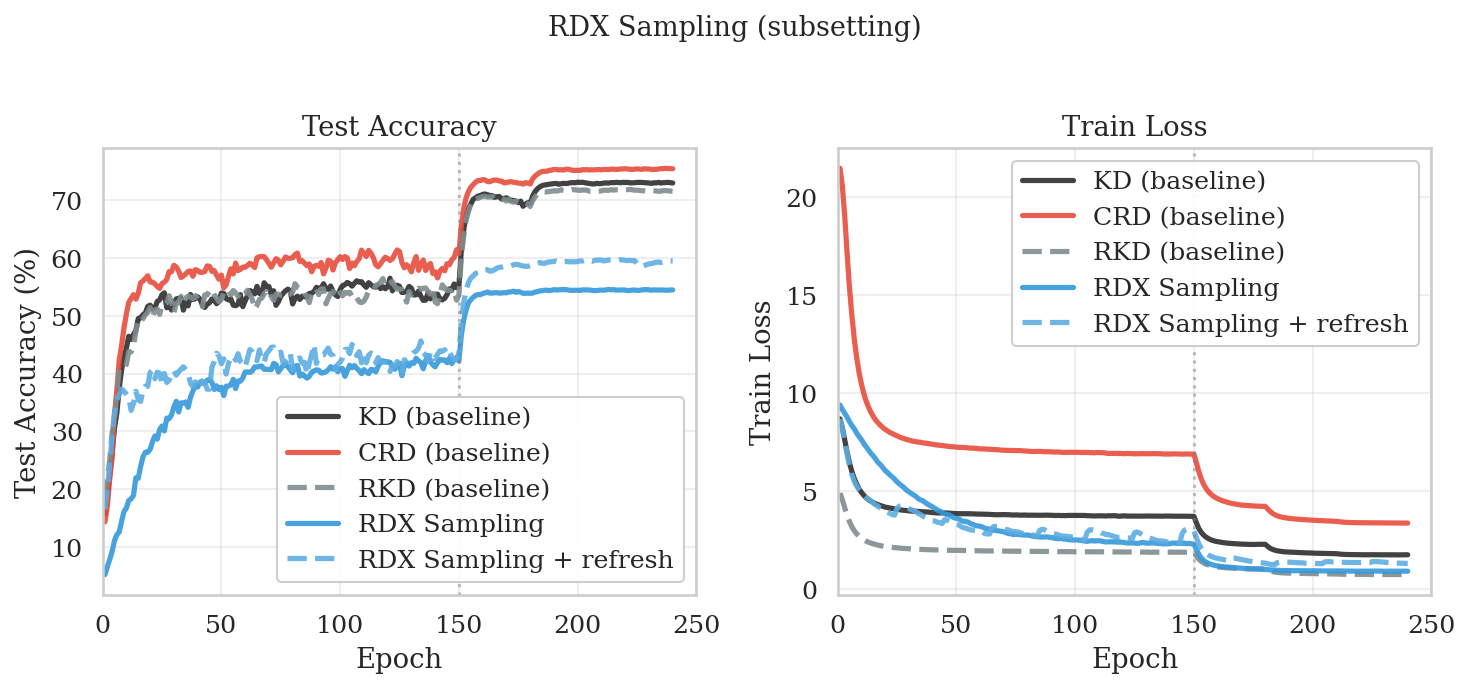

In [7]:
# Figure 2: RDX Sampling (subsetting)
FIG2_LABELS = ['KD (baseline)', 'CRD (baseline)', 'RKD (baseline)', 'RDX Sampling', 'RDX Sampling + refresh']

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for label in FIG2_LABELS:
    if label not in test_acc:
        continue
    steps, vals = smooth_curve(*test_acc[label], alpha=SMOOTH)
    axes[0].plot(steps, vals, label=label, color=COLORS[label],
                 linestyle=LINESTYLES[label], linewidth=2.5, alpha=0.9)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Test Accuracy')
axes[0].legend(loc='lower right', framealpha=0.95)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 250)
axes[0].axvline(150, color='gray', linestyle=':', alpha=0.5)

for label in FIG2_LABELS:
    if label not in train_loss:
        continue
    steps, vals = smooth_curve(*train_loss[label], alpha=SMOOTH)
    axes[1].plot(steps, vals, label=label, color=COLORS[label],
                 linestyle=LINESTYLES[label], linewidth=2.5, alpha=0.9)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Train Loss')
axes[1].set_title('Train Loss')
axes[1].legend(loc='upper right', framealpha=0.95)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 250)
axes[1].axvline(150, color='gray', linestyle=':', alpha=0.5)

fig.suptitle('RDX Sampling (subsetting)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../save/tensorboard_export/fig2_rdx_sampling.pdf')
plt.savefig('../save/tensorboard_export/fig2_rdx_sampling.png')
plt.show()

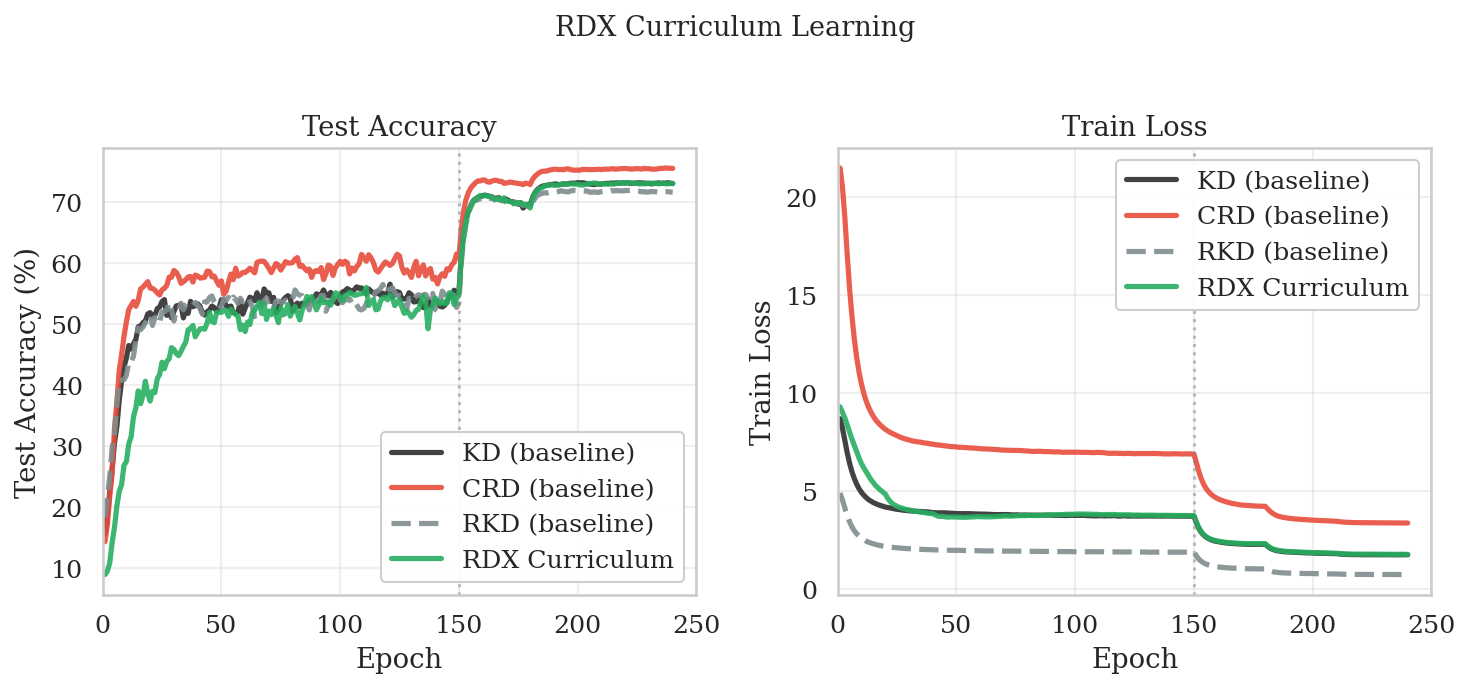

In [8]:
# Figure 3: RDX Curriculum Learning
FIG3_LABELS = ['KD (baseline)', 'CRD (baseline)', 'RKD (baseline)', 'RDX Curriculum']

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for label in FIG3_LABELS:
    if label not in test_acc:
        continue
    steps, vals = smooth_curve(*test_acc[label], alpha=SMOOTH)
    axes[0].plot(steps, vals, label=label, color=COLORS[label],
                 linestyle=LINESTYLES[label], linewidth=2.5, alpha=0.9)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Test Accuracy')
axes[0].legend(loc='lower right', framealpha=0.95)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 250)
axes[0].axvline(150, color='gray', linestyle=':', alpha=0.5)

for label in FIG3_LABELS:
    if label not in train_loss:
        continue
    steps, vals = smooth_curve(*train_loss[label], alpha=SMOOTH)
    axes[1].plot(steps, vals, label=label, color=COLORS[label],
                 linestyle=LINESTYLES[label], linewidth=2.5, alpha=0.9)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Train Loss')
axes[1].set_title('Train Loss')
axes[1].legend(loc='upper right', framealpha=0.95)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 250)
axes[1].axvline(150, color='gray', linestyle=':', alpha=0.5)

fig.suptitle('RDX Curriculum Learning', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../save/tensorboard_export/fig3_rdx_curriculum.pdf')
plt.savefig('../save/tensorboard_export/fig3_rdx_curriculum.png')
plt.show()

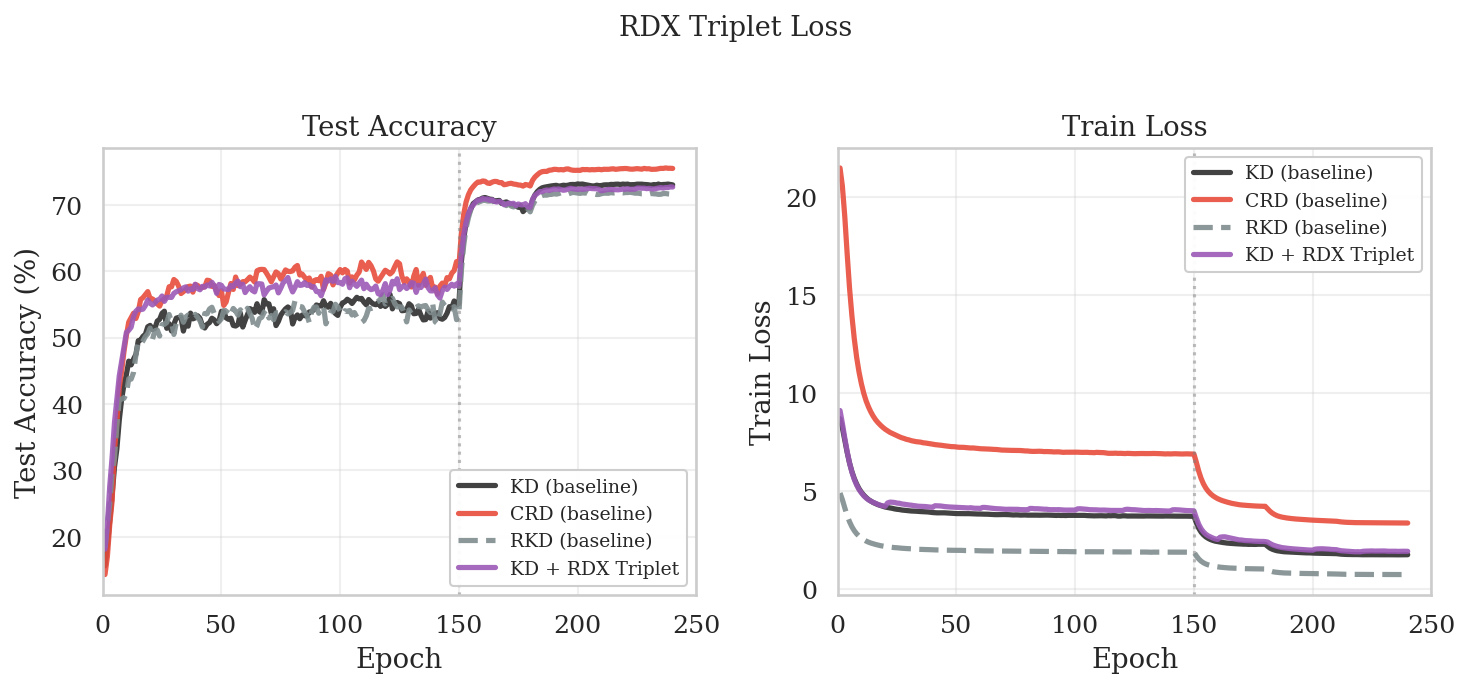

In [12]:
# Figure 4: RDD Loss
FIG4_LABELS = [
    'KD (baseline)', 'CRD (baseline)', 'RKD (baseline)',
    'KD + RDD',
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for label in FIG4_LABELS:
    if label not in test_acc:
        continue
    steps, vals = smooth_curve(*test_acc[label], alpha=SMOOTH)
    axes[0].plot(steps, vals, label=label, color=COLORS[label],
                 linestyle=LINESTYLES[label], linewidth=2.5, alpha=0.9)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Test Accuracy')
axes[0].legend(loc='lower right', framealpha=0.95, fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 250)
axes[0].axvline(150, color='gray', linestyle=':', alpha=0.5)

for label in FIG4_LABELS:
    if label not in train_loss:
        continue
    steps, vals = smooth_curve(*train_loss[label], alpha=SMOOTH)
    axes[1].plot(steps, vals, label=label, color=COLORS[label],
                 linestyle=LINESTYLES[label], linewidth=2.5, alpha=0.9)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Train Loss')
axes[1].set_title('Train Loss')
axes[1].legend(loc='upper right', framealpha=0.95, fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 250)
axes[1].axvline(150, color='gray', linestyle=':', alpha=0.5)

fig.suptitle('RDD Loss', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../save/tensorboard_export/fig4_rdx_triplet.pdf')
plt.savefig('../save/tensorboard_export/fig4_rdx_triplet.png')
plt.show()

In [13]:
# Summary: final test accuracy
print('Final test accuracy (epoch 240 or last):')
for label in ORDER:
    if label not in test_acc:
        continue
    steps, vals = test_acc[label]
    steps, vals = list(steps), list(vals)
    final = vals[-1]
    final_step = steps[-1]
    print(f'  {label}: {final:.2f}% (epoch {final_step})')

Final test accuracy (epoch 240 or last):
  KD (baseline): 72.93% (epoch 240)
  CRD (baseline): 75.45% (epoch 240)
  RKD: 71.55% (epoch 240)
  RDX Sampling: 54.53% (epoch 240)
  RDX Sampling + refresh: 59.49% (epoch 240)
  RDX Curriculum: 72.96% (epoch 240)
  KD + RDD: 72.38% (epoch 211)
  KD + RDD (affinity): 72.66% (epoch 240)
  KD + RDD (β=10): 1.00% (epoch 90)
  RDD only: 55.84% (epoch 128)
